#**Sentiment analysis using LSTM RNN**

> This notebook is part of my learning journey in deep learning fundamentals.
> Focus is on understanding concepts rather than achieving maximum accuracy.

# Objective

This notebook aims to demonstrate the process of building and evaluating a **Recurrent Neural Network (RNN)** using **<font color=cyan>TensorFlow</font>** to classify movie reviews as positive or negative (**Sentiment Analysis**) while harnessing the capabilitites of **Long Short-Term Memory (LSTM)**. Specifically, I have used the IMDB dataset from **<font color=cyan>keras</font>** library.
The major layers included in this RNN model are **Embedding layer**, **LSTM layer** and **Dense layer**.

#**Importing Libraries**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models

import warnings
warnings.filterwarnings('ignore')

#**<font color='red'>1.</font> Loading Dataset**

In [ ]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocab_size)

print(f"X_train length : {len(X_train)}")
print(f"X_test length : {len(X_test)}")
print("\nX_train sample : ")
print(X_train[0][:20])
print("\nLabel:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train length : 25000
X_test length : 25000

X_train sample : 
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]

Label: 1


#**<font color='red'>2.</font> Pre-processing**

##**Padding**
Each review is a sequence of integers representing words. These sequences have different lengths.

Neural networks require inputs of equal length. We pad all sequences to a fixed length using zeros. This ensures consistent input shape for training.

In [ ]:
max_length = 200

X_train_padded = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length)
X_test_padded = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length)

print(X_train_padded.shape)

(25000, 200)


#**<font color='red'>3.</font> Train the LSTM RNN Model**

In [ ]:
# Define the basic RNN Model
rnn = models.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    layers.LSTM(32),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Model training
history = rnn.fit(
    X_train_padded, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.7833 - loss: 0.4554 - val_accuracy: 0.8620 - val_loss: 0.3372
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 91ms/step - accuracy: 0.9056 - loss: 0.2479 - val_accuracy: 0.8566 - val_loss: 0.3440
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.9339 - loss: 0.1814 - val_accuracy: 0.8758 - val_loss: 0.3261


#**<font color='red'>4.</font> Evaluate the RNN Model**

In [ ]:
test_loss, test_acc = rnn.evaluate(X_test_padded, y_test)
print("Test accuracy:", test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8638 - loss: 0.3467
Test accuracy: 0.8637999892234802


#**Simple RNN v/s LSTM RNN**



*   LSTM's performance is better as compared to the simple RNN model with final train accuracy of **93.39%**, Validation accuracy of **87.58%** and Test accuracy of **86.38%**

*   The improvement in accuracy is likely due to the LSTM's ability to overcome the **vanishing gradient problem**

*   LSTM is much better at capturing context across words
*   LSTM is slightly slower to train than SimpleRNN but provides more stable validation accuracy



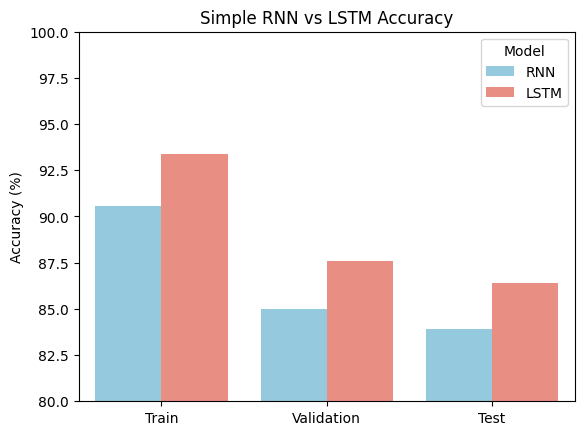

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Metric': ['Train', 'Validation', 'Test', 'Train', 'Validation', 'Test'],
    'Accuracy': [90.56, 85.00, 83.89, 93.39, 87.58, 86.38],
    'Model': ['RNN', 'RNN', 'RNN', 'LSTM', 'LSTM', 'LSTM']
}
df = pd.DataFrame(data)

sns.barplot(data=df, x='Metric', y='Accuracy', hue='Model', palette=['skyblue', 'salmon'])

plt.ylim(80, 100)
plt.xlabel('')
plt.ylabel('Accuracy (%)')
plt.title('Simple RNN vs LSTM Accuracy')
plt.show()